# AURA Tutorial: Human Reactive Lymph Node (10x Xenium)

This notebook demonstrates **AURA** (composition-dependent context variance model) on
a [10x Xenium Prime Human Reactive Lymph Node](https://www.10xgenomics.com/datasets)
dataset processed with **NEBULA** for identity-weighted cell type assignments.

## What is AURA?

AURA tests whether gene expression variance within a **focal cell type** is structured
by the **local neighborhood composition** — i.e., which cell types surround each cell.

For example: do Tfh cells near germinal center B cells express different genes than
Tfh cells in the T cell zone? AURA detects these composition-dependent expression
programs without requiring predefined spatial domains.

### Key concepts

| Term | Definition |
|:---|:---|
| **Focal type** | The cell type being analyzed (e.g., Tfh) |
| **Composition** | Fraction of each cell type among k nearest neighbors |
| **Beta vector** | Per-gene effect: how expression responds to each composition axis |
| **R²_total** | Fraction of total gene variance explained by composition |

### Workflow

1. Load tissue data (h5ad with spatial coordinates and cell type labels)
2. Select a focal cell type and extract its count matrix
3. Run the AURA permutation test
4. Diagnose model fit (QQ plots, variance decomposition)
5. Interpret results (SVD of beta vectors, gene zoom panels)

## Prerequisites

- `aura` package installed (`pip install -e .` from the aura repo)
- `lymphnode_nebula_counts.h5ad` — NEBULA-annotated Xenium data with columns:
  - `x_centroid`, `y_centroid` — spatial coordinates
  - `lineage_aura` — 10 lineage-level cell type labels (composition axes)
  - `cell_type_nebula` — fine-grained cell type labels (for focal type selection)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aura

print(f'AURA version: {aura.__version__}')

AURA version: 0.1.0


In [2]:
# ================================================================
# Paths
# ================================================================
DATA_PATH = '/Users/mchen12/SpatialHeterogeneity/data/lymphnode_nebula_counts.h5ad'

# ================================================================
# Analysis parameters
# ================================================================
K = 30              # number of spatial nearest neighbors for composition
                    # k=30 captures the local niche (~2-3 cell diameters)
                    # for Xenium data with ~5-7 µm median cell spacing.

N_PERM = 5000       # number of permutations for the test
                    # 5000 gives p-value resolution of ~2e-4.
                    # Use 1000 for quick exploration, 5000+ for final results.

ALPHA = 0.05        # FDR threshold for significance

---
## 1. Load Data

AURA expects an h5ad file with:
- A sparse or dense expression matrix (`.X`)
- Spatial coordinates in `.obs` (default: `x_centroid`, `y_centroid`)
- Cell type labels in `.obs` for defining composition axes

`load_adata()` extracts tissue-wide coordinates and integer-encoded cell types.
The `type_column` parameter specifies which `.obs` column defines the composition
axes — typically a lineage-level annotation (10–15 types) rather than fine-grained
subtypes.

In [3]:
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s: %(message)s')

tissue = aura.load_adata(
    DATA_PATH,
    xy_columns=('x_centroid', 'y_centroid'),
    type_column='lineage_aura',
)

print(f'\nTissue summary:')
print(f'  Cells: {tissue.adata.n_obs:,}')
print(f'  Genes: {tissue.adata.n_vars:,}')
print(f'  Cell types ({len(tissue.type_names)}): {tissue.type_names}')

print(f'\nCells per lineage:')
for name in tissue.type_names:
    n = (tissue.all_types == tissue.type_to_int[name]).sum()
    print(f'  {name:15s}: {n:>6,}')

aura.io: Loaded 702207 cells, 4624 genes, 10 types from /Users/mchen12/SpatialHeterogeneity/data/lymphnode_nebula_counts.h5ad



Tissue summary:
  Cells: 702,207
  Genes: 4,624
  Cell types (10): ['B', 'Endo', 'FDC', 'GC_B', 'Mac', 'Other', 'Stromal', 'T_conv', 'Tfh', 'Treg']

Cells per lineage:
  B              : 132,249
  Endo           : 61,758
  FDC            :  2,272
  GC_B           : 13,557
  Mac            : 47,934
  Other          : 28,930
  Stromal        : 85,763
  T_conv         : 317,302
  Tfh            :  2,773
  Treg           :  9,669


---
## 2. Visualize Tissue Layout

Before running AURA, inspect the spatial distribution of cell types to identify which
focal types are embedded in **variable neighborhoods** — these will have the most power.

The design principle: *the focal type should be the one whose context varies, not the one
that constitutes the context.* Rarer cell types embedded in mixed regions yield more
composition variation and therefore more statistical power.

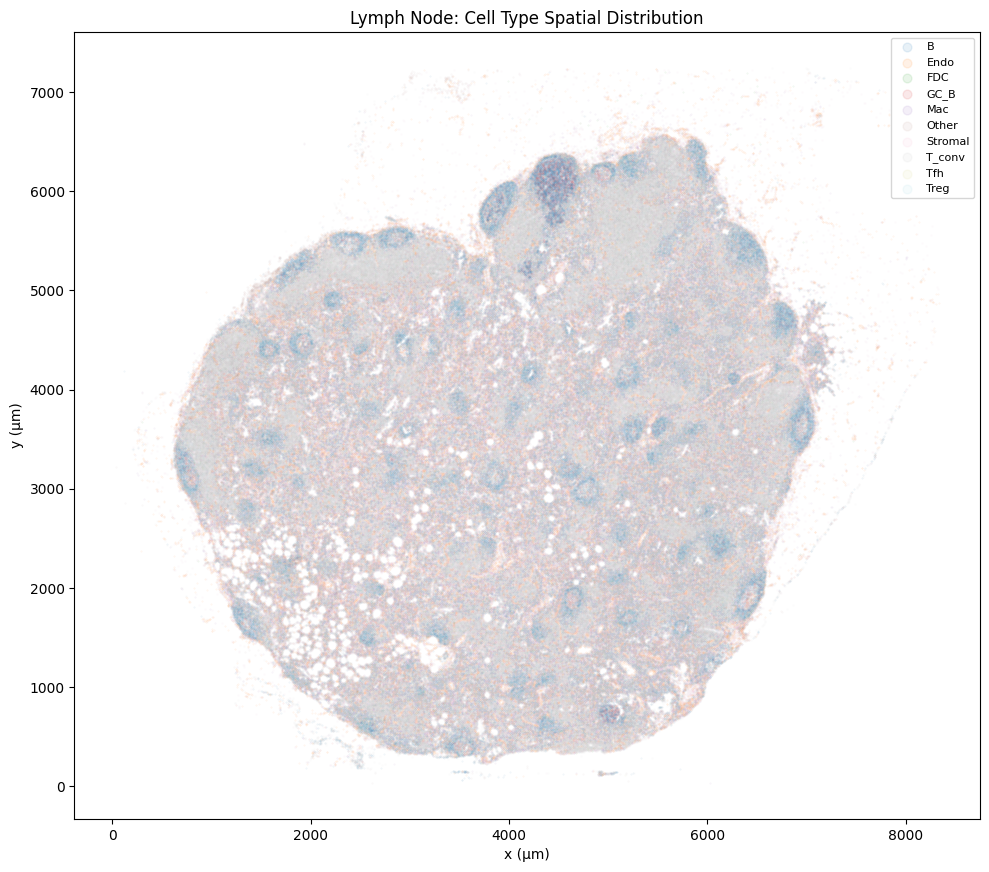

In [4]:
# Spatial overview: all cells colored by lineage
type_colors = plt.cm.tab20(np.linspace(0, 1, len(tissue.type_names)))

fig, ax = plt.subplots(figsize=(10, 10))
for i, name in enumerate(tissue.type_names):
    mask = tissue.all_types == i
    ax.scatter(tissue.all_xy[mask, 0], tissue.all_xy[mask, 1],
               c=[type_colors[i]], s=0.1, alpha=0.1, label=name, rasterized=True)
ax.set_aspect('equal')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Lymph Node: Cell Type Spatial Distribution')
ax.legend(markerscale=20, fontsize=8, loc='upper right', framealpha=0.8)
plt.tight_layout()
plt.show()

---
## 3. Run AURA on Tfh Cells

**Tfh (T follicular helper)** cells are an ideal focal type for this tissue because they
sit at the interface between T cell zones and germinal centers, experiencing highly variable
neighborhood composition. Some Tfh cells are surrounded by GC B cells (inside germinal
centers), while others are in T-cell-rich paracortex.

`run_aura()` is the main entry point. It:
1. Extracts focal cells and filters genes by mean expression
2. Estimates NB dispersion and computes Pearson residuals
3. Builds kNN composition vectors
4. Runs the permutation test with batched low-rank decomposition
5. Computes effect sizes (beta vectors) and variance decomposition
6. Returns an `AuraResult` object with all outputs

In [5]:
import time

t0 = time.time()
result = aura.run_aura(
    tissue,
    focal_label='Tfh',
    label_column='cell_type_nebula',
    k=K,
    n_perm=N_PERM,
    alpha=ALPHA,
)
elapsed = time.time() - t0

print(f'\nCompleted in {elapsed:.0f}s')
print(f'Focal cells: {result.counts.shape[0]:,}')
print(f'Genes tested: {result.n_genes}')
print(f'Significant: {result.n_significant} ({result.n_significant/result.n_genes*100:.0f}%)')

aura.io: Focal cells (Tfh): 2773


aura.io: Genes (mean >= 0.10): 1022


aura.model: Dispersion phi = 6.49


aura.model: Significant genes: 122 / 1022 (FDR < 0.05)


aura.model: Filtered 2 genes with no excess variance (124 before filter)



Completed in 2s
Focal cells: 2,773
Genes tested: 1022
Significant: 122 (12%)


In [6]:
# Print top significant genes
sig_idx = np.where(result.significant)[0]
top = sig_idx[np.argsort(result.R2_total[sig_idx])[::-1]]

print(f'Top 15 context-responsive genes in Tfh:')
print(f'{"Gene":15s} {"R²_total":>9s} {"Detection":>10s} {"Driver axis":>15s} {"Beta":>7s}')
print(f'{"─"*15} {"─"*9} {"─"*10} {"─"*15} {"─"*7}')
for i in top[:15]:
    gidx = np.where(result.gene_names == result.gene_names[i])[0][0]
    det = (result.counts[:, gidx] > 0).mean()
    driver = np.argmax(np.abs(result.beta[i]))
    sign = '+' if result.beta[i, driver] > 0 else '-'
    print(f'{result.gene_names[i]:15s} {result.R2_total[i]:8.2%} '
          f'{det:9.0%} {sign}{result.type_names[driver]:>14s} '
          f'{result.beta[i, driver]:+6.1f}')

Top 15 context-responsive genes in Tfh:
Gene             R²_total  Detection     Driver axis    Beta
─────────────── ───────── ────────── ─────────────── ───────
TOX2               7.44%        8% +          GC_B  +10.1
IKZF3              3.15%       27% -           FDC   -7.8
CR2                2.25%        4% +           Tfh  +15.1
MAF                2.12%       15% +           Tfh   +5.8
PDCD1              2.06%        7% +          GC_B   +3.3
CXCL13             1.98%        3% +           Tfh   +2.6
TIGIT              1.87%       12% +          GC_B   +3.7
SH2D1A             1.48%       13% +          GC_B   +3.5
POU2AF1            1.27%        8% +          GC_B   +2.2
ICA1               1.19%        7% +          GC_B   +1.9
LEF1               1.16%       16% -           FDC   -3.4
TOX                0.99%        8% +           Tfh   +6.1
SLC40A1            0.93%       13% +           Tfh   +6.9
PKM                0.89%       47% +          GC_B   +2.8
CD82               0.86%  

---
## 4. Diagnostics

Before interpreting results, check that the model is well-calibrated:

### `diagnostic_panel()` — 8 panels

| Panel | What to check |
|:---|:---|
| (a) Mean-variance fit | NB curve should track the gene cloud |
| (b) Residual variance | Median should be near 1.0 |
| (c-d) Cell effect | α_i should be small and weakly correlated with library size |
| (e) QQ all genes | Significant genes lift off the diagonal; null genes follow it |
| (f) QQ low-R² genes | Bottom 25% R² genes should be uniform (KS p > 0.05) |
| (g) p-value histogram | Spike at 0 for signal, flat for null |
| (h) R²_resid vs R²_total | Should be positively correlated |

/Users/mchen12/aura/aura/plot/diagnostics.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


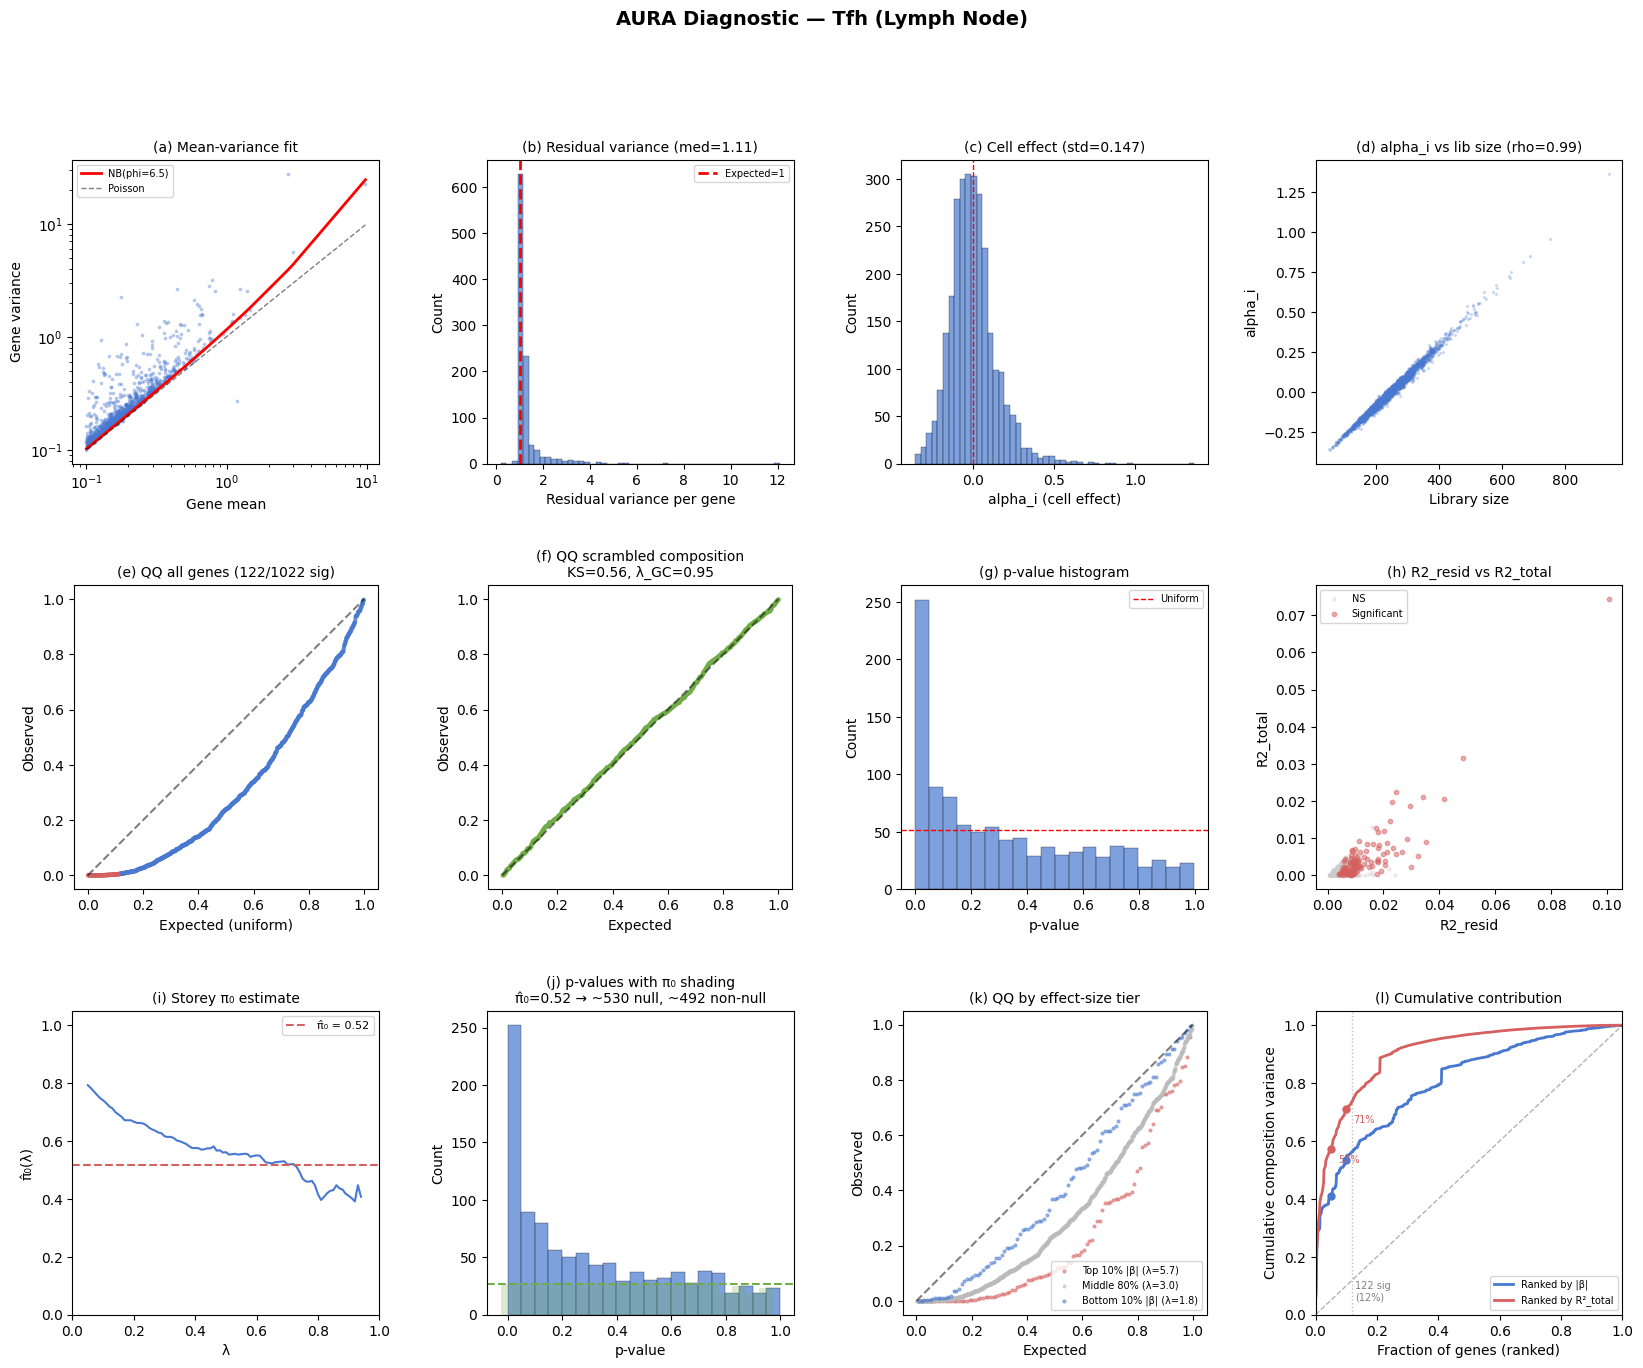

In [7]:
fig = aura.diagnostic_panel(result, title='AURA Diagnostic — Tfh (Lymph Node)')
plt.show()

---
## 5. Variance Decomposition

AURA decomposes the total variance of each gene into four components:

| Component | Source |
|:---|:---|
| **Baseline (NB)** | Expected sampling variance under negative binomial null |
| **Library size (α)** | Shared cell-level shift correlated with total RNA |
| **Composition (β)** | Variance explained by neighborhood composition — the AURA signal |
| **Unexplained** | Residual variance beyond the above three |

For most genes, baseline NB variance dominates (~90%+). The composition component is
small in absolute terms but biologically meaningful for significant genes.

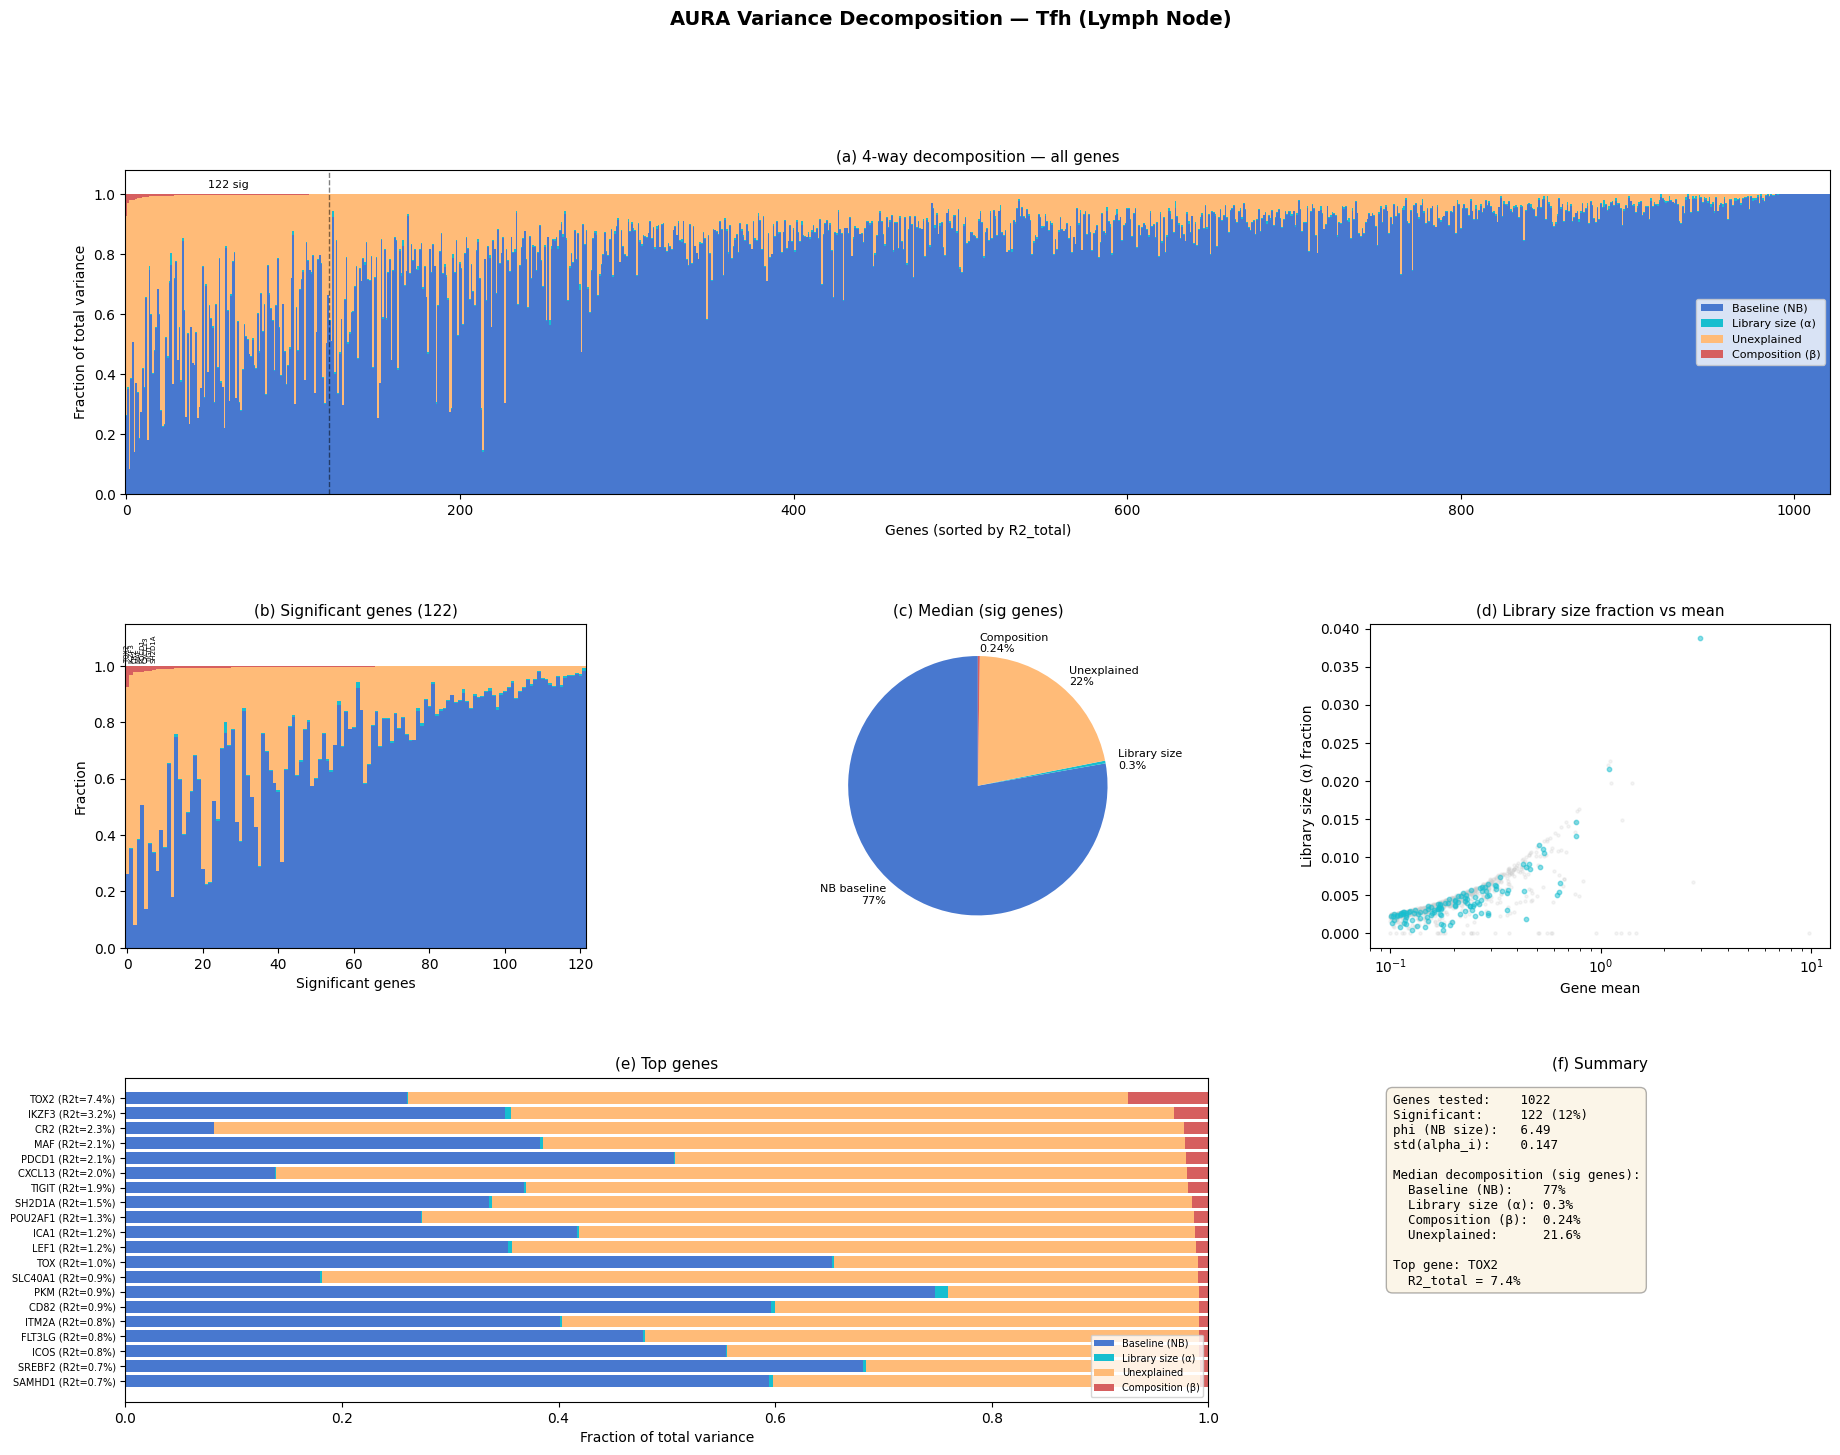

In [8]:
fig = aura.variance_panel(result, title='AURA Variance Decomposition — Tfh (Lymph Node)')
plt.show()

In [9]:
# Text-based summary
_ = aura.variance_summary(result=result, focal_name='Tfh')

  AURA Variance Decomposition — Tfh

Genes tested:  1022
Significant:   122 (12%)
Filtered (no excess var): 2

--- Variance decomposition (median across genes) ---

                                  All genes  Significant
                               ──────────── ────────────
Baseline (NB sampling)                  88%          77%
Excess variance                         12%          23%
  ├─ Composition-explained            0.04%        0.24%
  └─ Unexplained                      11.5%        22.3%

--- Top 10 composition-responsive genes ---

Gene            R2_total  Baseline  Excess   Comp Driver axis
─────────────── ──────── ───────── ─────── ────── ────────────────────
TOX2               7.4%      26%    74%  7.4% +GC_B
IKZF3              3.2%      35%    65%  3.2% -FDC
CR2                2.3%       8%    92%  2.3% +Tfh
MAF                2.1%      38%    62%  2.1% +Tfh
PDCD1              2.1%      51%    49%  2.1% +GC_B
CXCL13             2.0%      14%    86%  2.0% +Tfh
TIGIT 

---
## 6. SVD Result Panel

The beta matrix (n_significant × K) captures how each gene responds to each composition
axis. SVD decomposes this into **principal composition modes** — shared patterns of
context-dependent regulation.

### Interpreting the SVD panel

- **Row 1 (PC modes)**: Each bar chart shows one PC's loading on the composition axes.
  PC1 captures the dominant composition gradient (e.g., GC_B ↔ T_conv).
- **Row 2 (PC scatters)**: Genes plotted by their scores on PC1/PC2/PC3. Size ∝ R²_total.
  Outlier genes respond most strongly to that composition mode.
- **Top genes bar**: R²_total decomposed by PC contribution for the strongest genes.

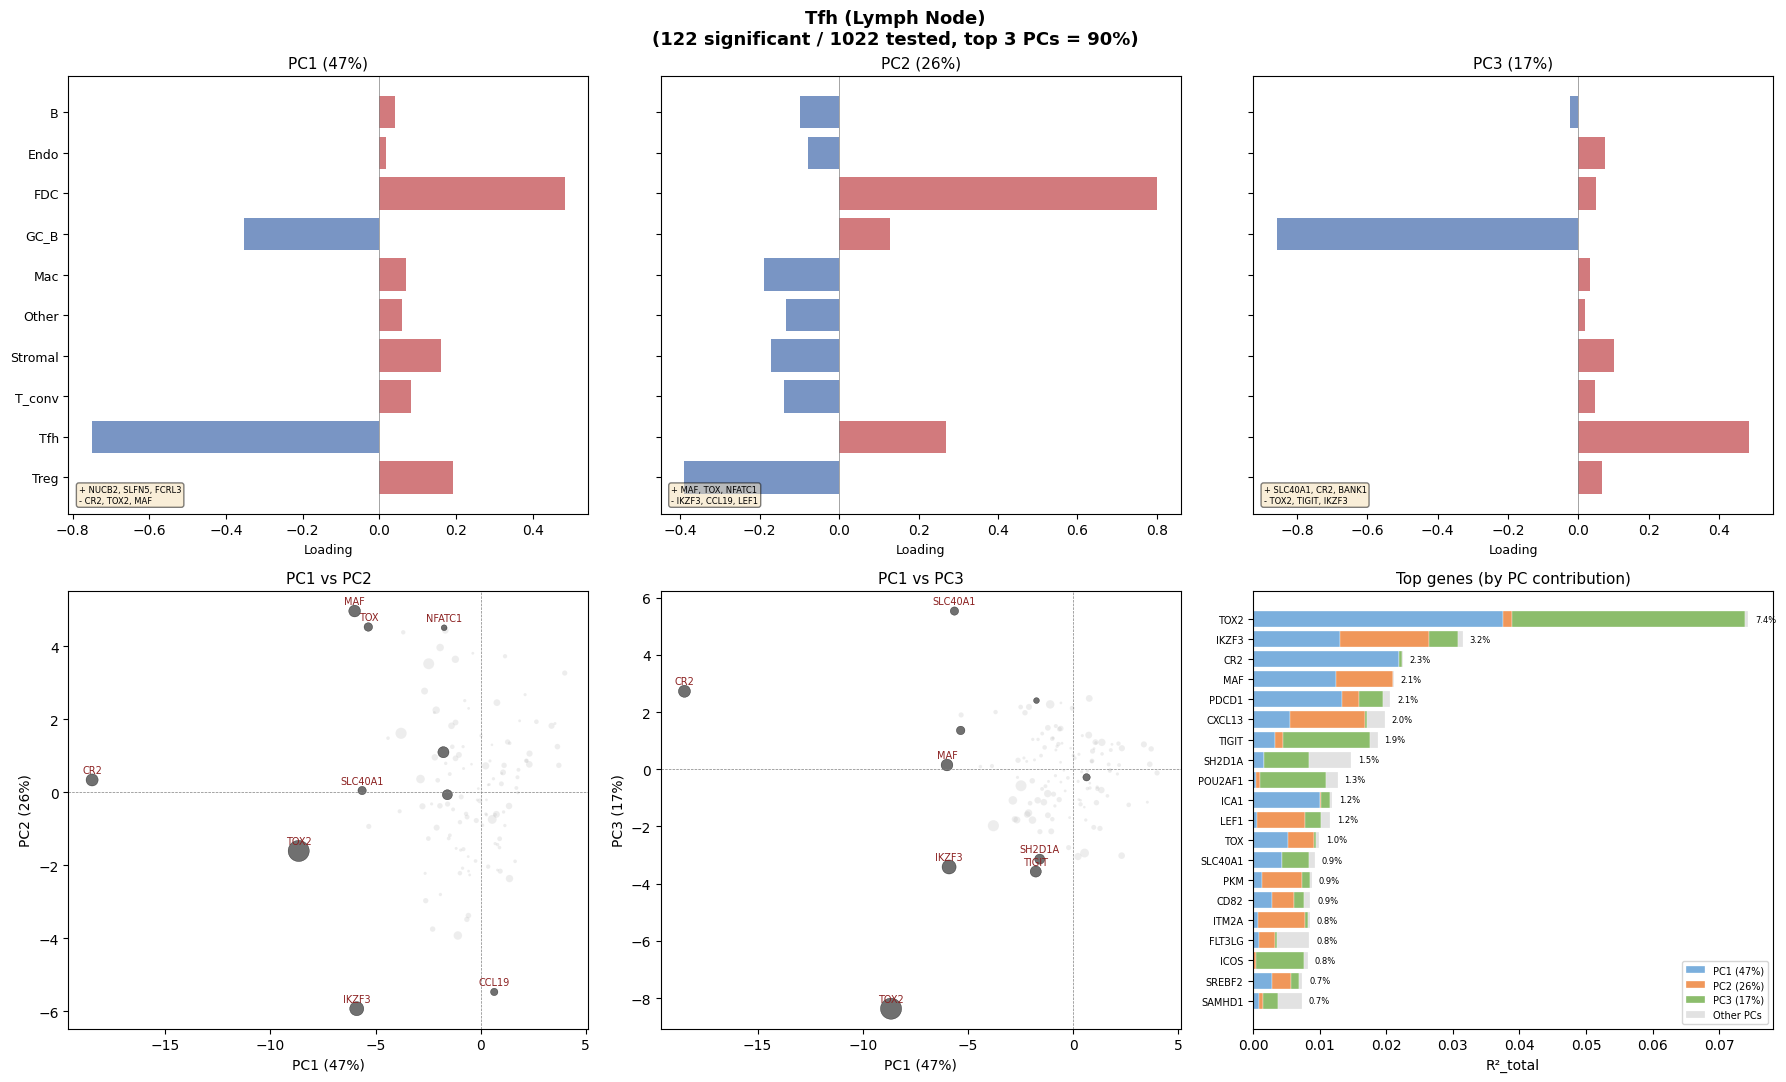

In [10]:
fig = aura.result_panel(result=result, title='Tfh (Lymph Node)')
plt.show()

---
## 7. Gene Zoom: TOX2

`gene_zoom_panel()` provides a single-gene deep dive with spatial and compositional views:

- **Row 1**: Spatial expression map (purple = expressing cells) + beta bar chart
- **Rows 2–4**: For each top driver axis: spatial composition map (YlOrRd) with
  expressing cells circled, and a scatter showing mean expression + detection rate
  as a function of that composition axis

**TOX2** is the top context-responsive gene in Tfh (R²_total = 7.4%). It encodes a
transcription factor critical for Tfh differentiation and is known to be upregulated
in germinal center Tfh cells. AURA detects this as a strong positive association with
GC_B neighbor fraction.

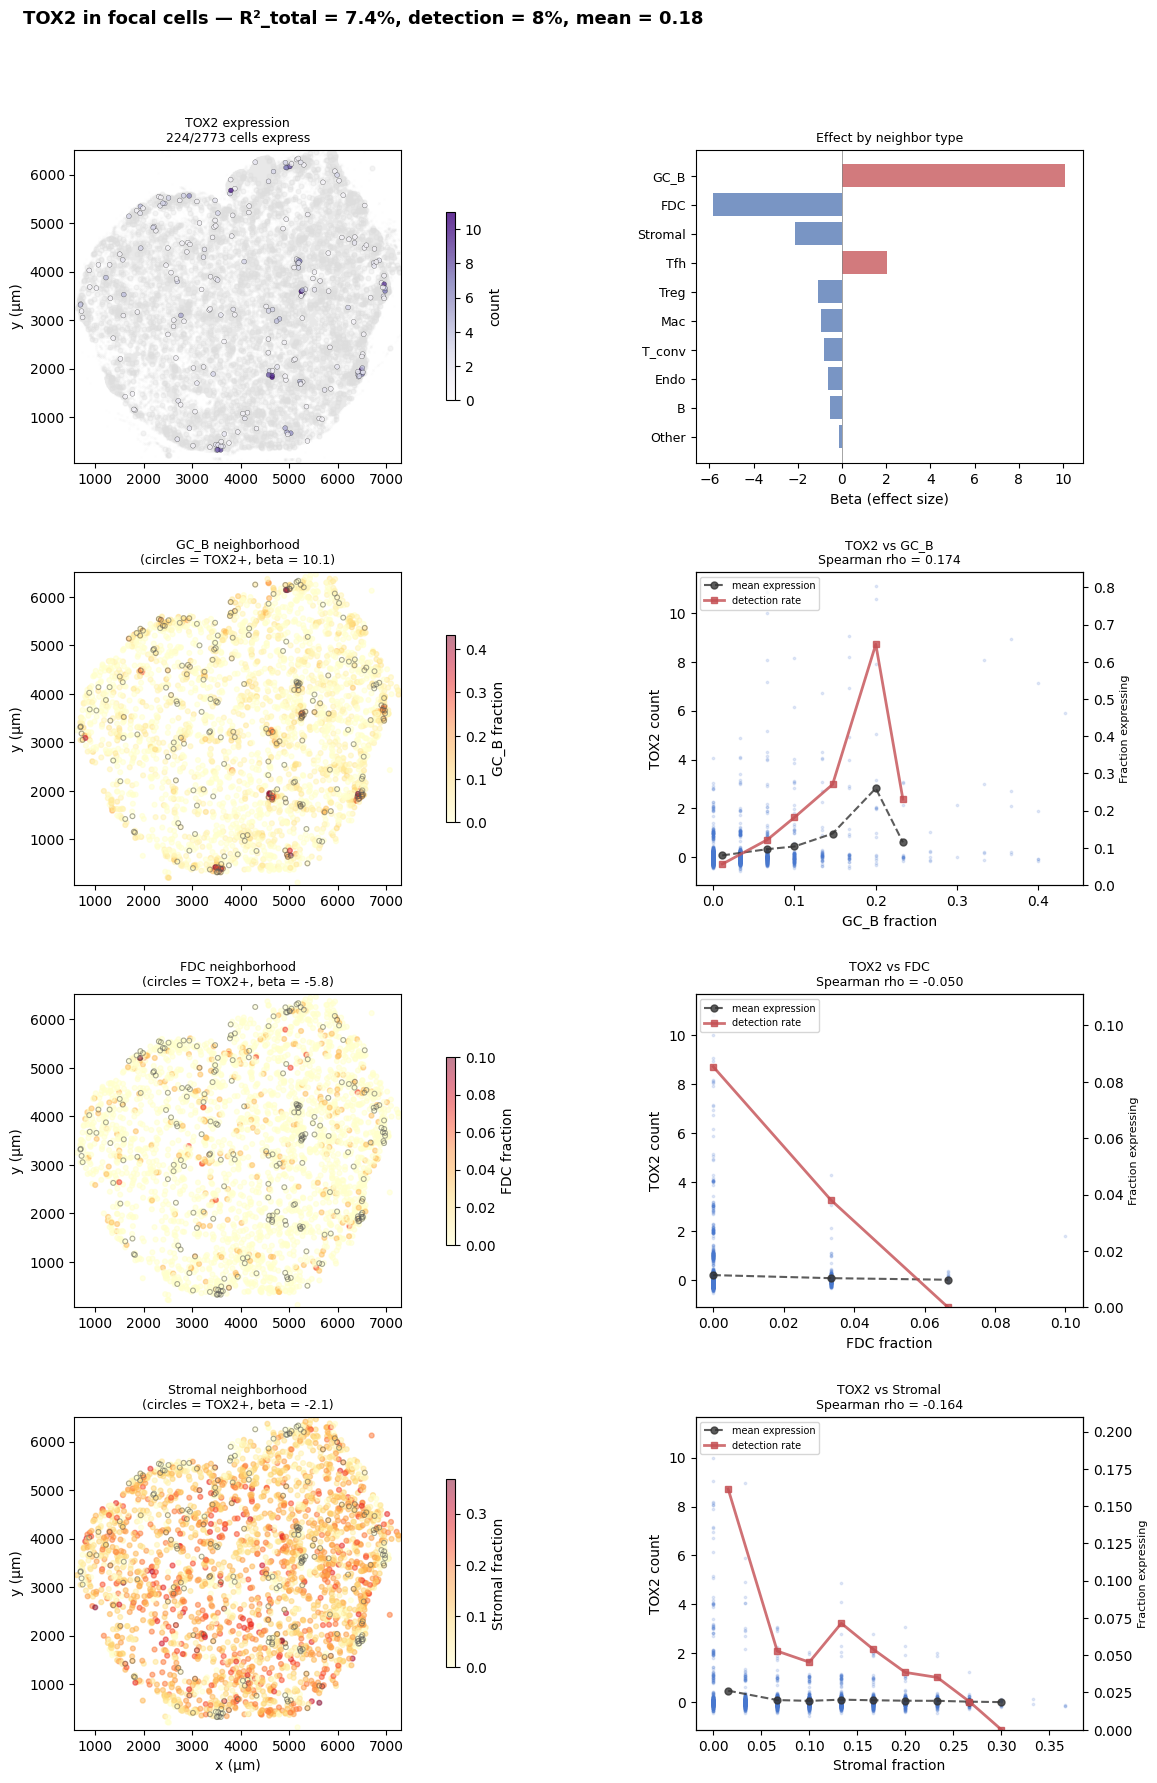

In [11]:
# Background cell masks for spatial context
bg_masks = [
    (tissue.adata.obs['lineage_aura'] == 'B').values,
    (tissue.adata.obs['lineage_aura'] == 'GC_B').values,
    (tissue.adata.obs['lineage_aura'] == 'FDC').values,
]

fig = aura.gene_zoom_panel(
    'TOX2', result,
    all_xy=tissue.all_xy,
    bg_masks=bg_masks,
    dot_size=12,
)
plt.show()

### Gene Zoom: IKZF3

**IKZF3** (Aiolos) is the second-highest R²_total gene. It is an Ikaros family
transcription factor involved in B/T cell differentiation. Its context-dependence in Tfh
cells reflects the germinal center niche influence on Tfh transcriptional programs.

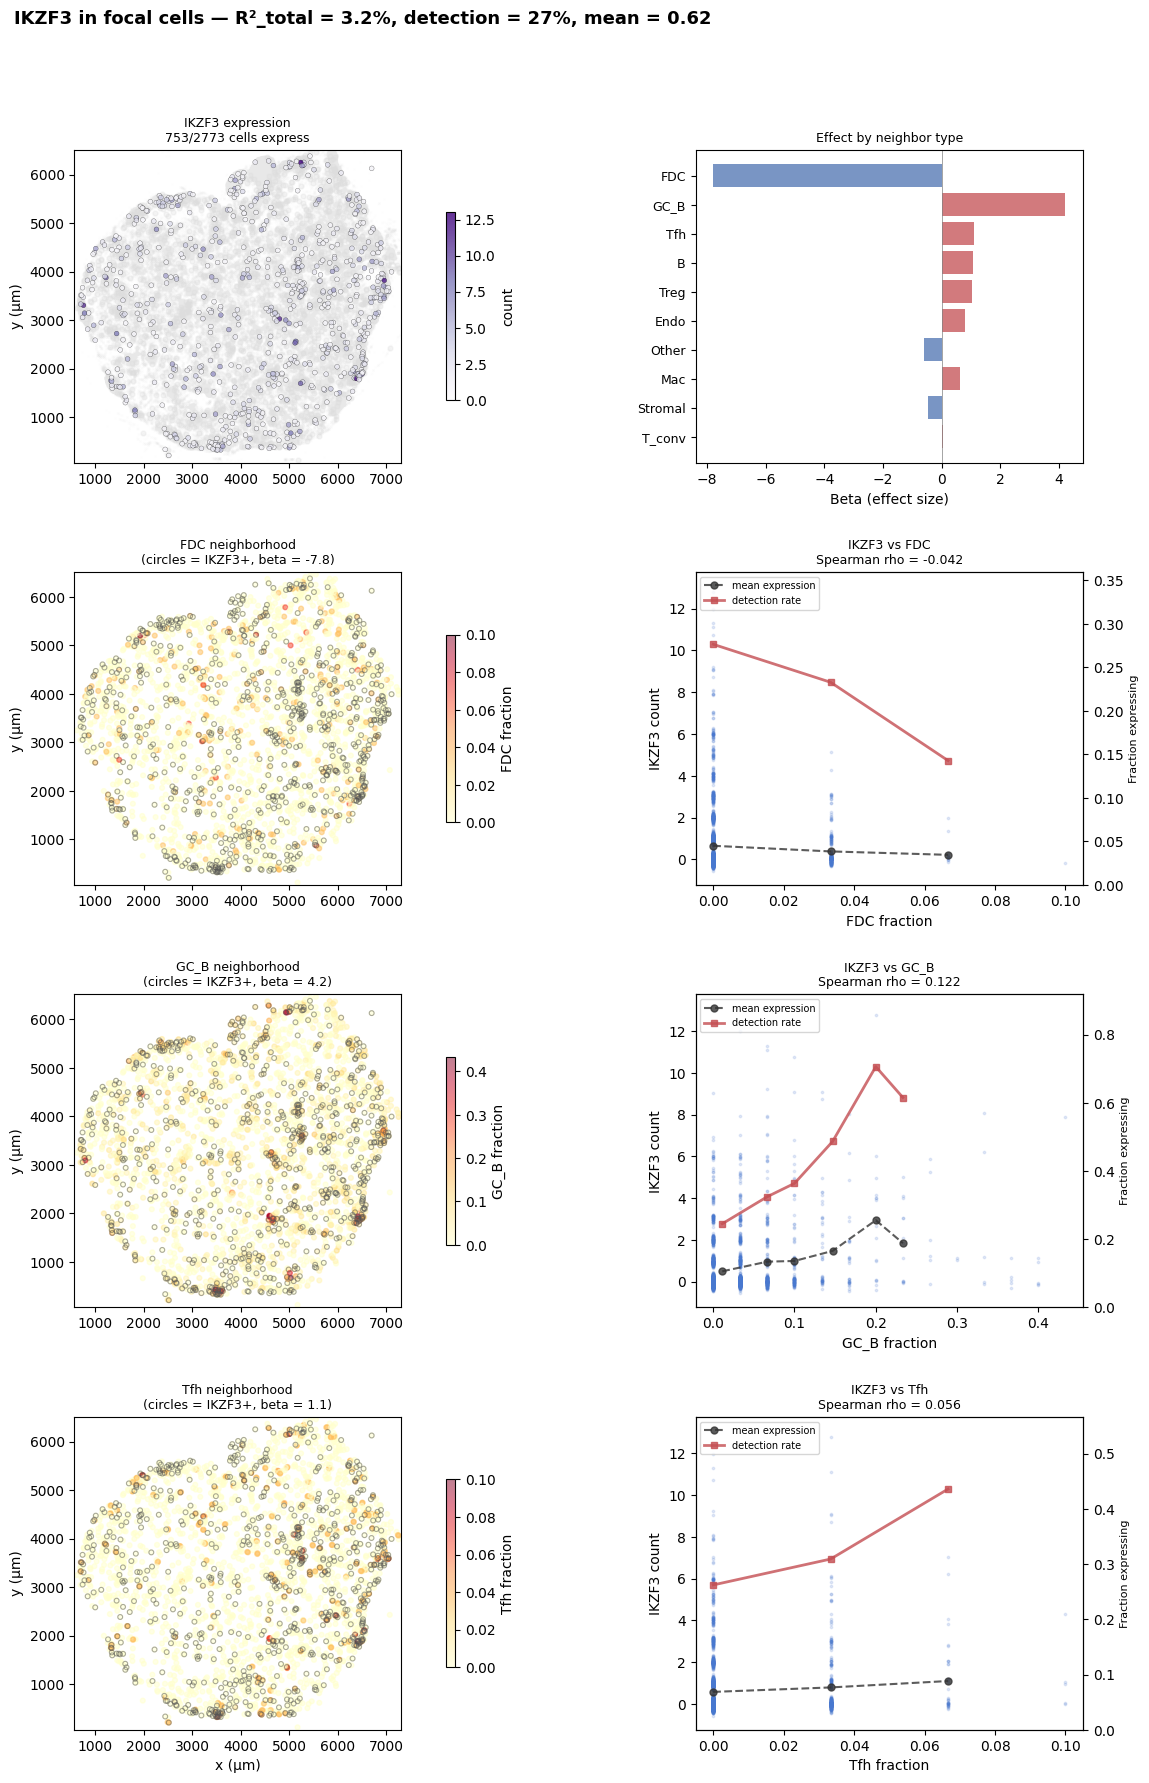

In [12]:
fig = aura.gene_zoom_panel(
    'IKZF3', result,
    all_xy=tissue.all_xy,
    bg_masks=bg_masks,
    dot_size=12,
)
plt.show()

---
## 8. Running Multiple Focal Types

AURA can be applied to any cell type in the tissue. Here we run it on a second focal
type — **Macrophages** — to demonstrate the workflow generalization and compare which
composition axes drive gene expression in different cell types.

In [13]:
t0 = time.time()
result_mac = aura.run_aura(
    tissue,
    focal_label='Macrophage',
    label_column='cell_type_nebula',
    k=K,
    n_perm=N_PERM,
    alpha=ALPHA,
)
elapsed = time.time() - t0

print(f'\nCompleted in {elapsed:.0f}s')
print(f'Focal cells: {result_mac.counts.shape[0]:,}')
print(f'Genes tested: {result_mac.n_genes}')
print(f'Significant: {result_mac.n_significant} ({result_mac.n_significant/result_mac.n_genes*100:.0f}%)')

aura.io: Focal cells (Macrophage): 47934


aura.io: Genes (mean >= 0.10): 867


aura.model: Dispersion phi = 0.88


aura.model: Significant genes: 527 / 867 (FDR < 0.05)


aura.model: Filtered 298 genes with no excess variance (825 before filter)



Completed in 29s
Focal cells: 47,934
Genes tested: 867
Significant: 527 (61%)


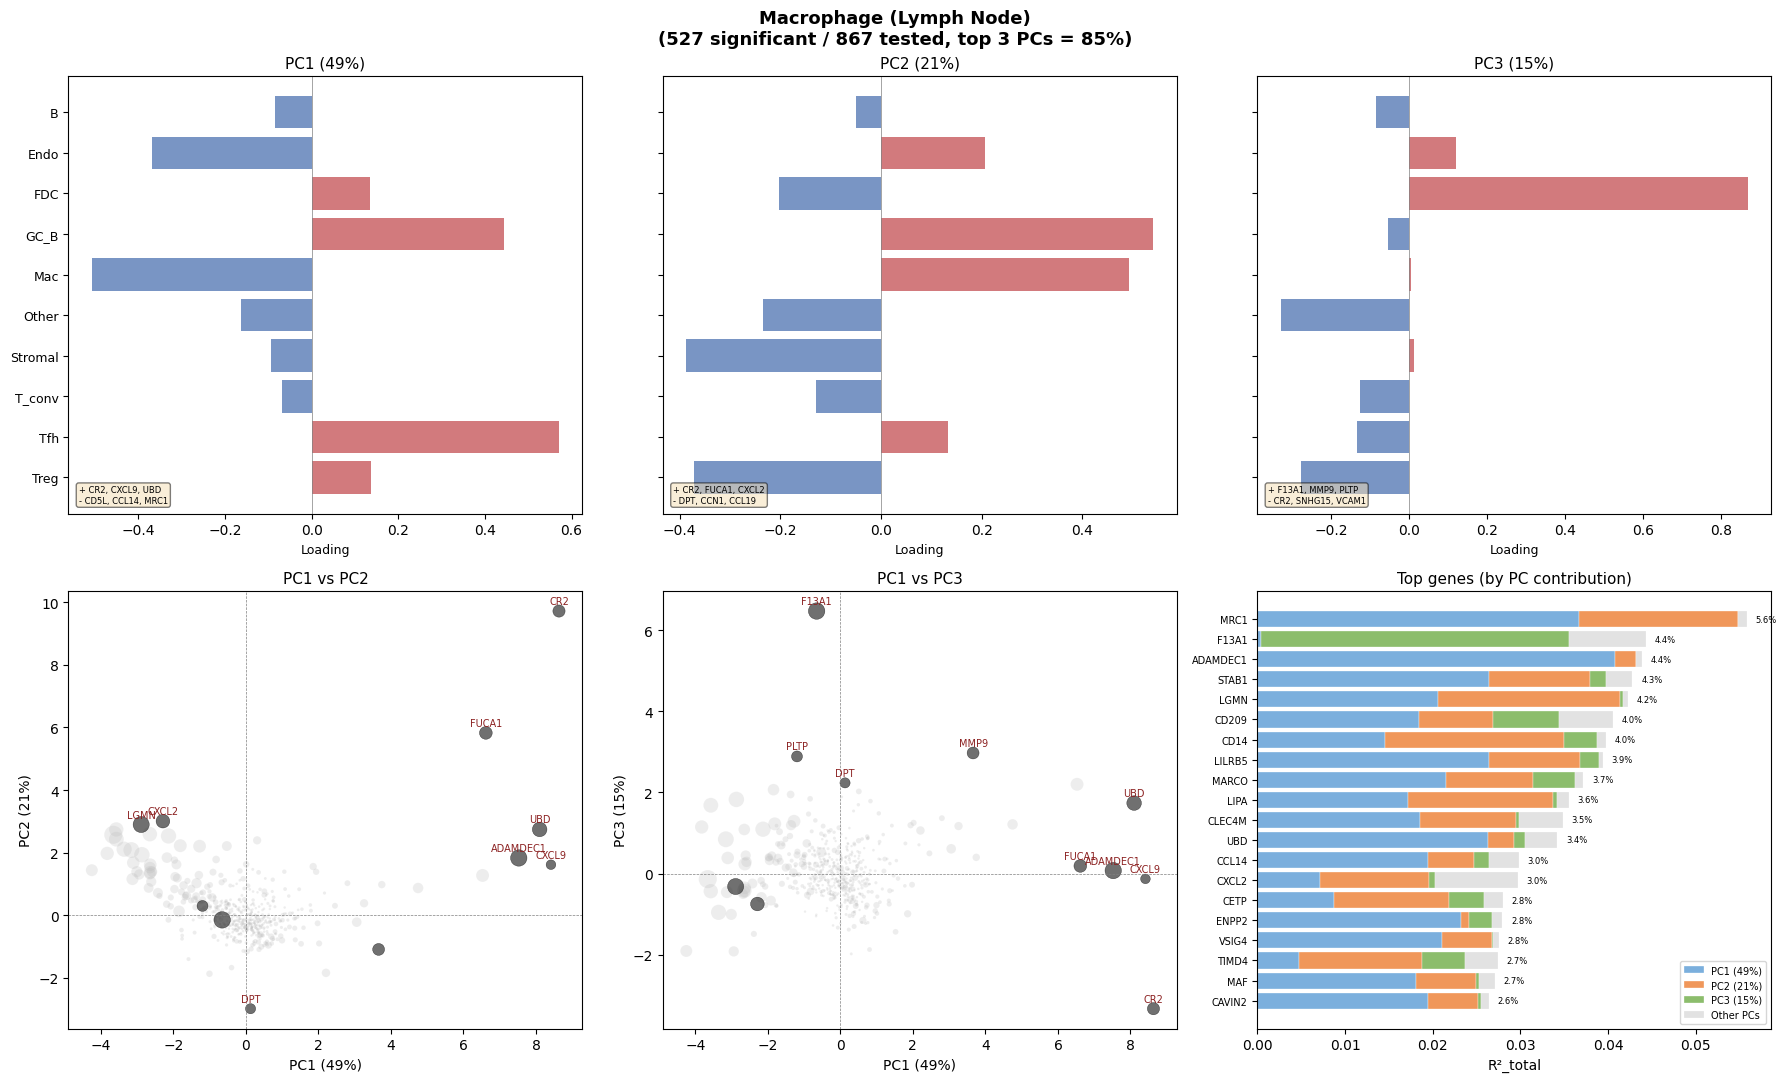

In [14]:
fig = aura.result_panel(result=result_mac, title='Macrophage (Lymph Node)')
plt.show()

---
## 9. Save Results

Save the AURA results as CSV files for downstream analysis or cross-focal comparisons.
The CSV schema includes gene-level statistics and per-axis beta coefficients.

In [15]:
import os
os.makedirs('results', exist_ok=True)

result.save('results/aura_Tfh.csv')
result_mac.save('results/aura_Macrophage.csv')

# Verify saved CSV
import pandas as pd
df = pd.read_csv('results/aura_Tfh.csv')
print(f'Saved Tfh results: {len(df)} genes, {df["significant"].sum()} significant')
print(f'Columns: {list(df.columns)}')

aura.io: Saved results: results/aura_Tfh.csv (1022 genes, 122 significant)


aura.io: Saved results: results/aura_Macrophage.csv (867 genes, 527 significant)


Saved Tfh results: 1022 genes, 122 significant
Columns: ['gene', 'significant', 'has_excess', 'R2_total', 'R2_resid', 'total_var', 'baseline_var', 'excess_var', 'Q', 'pvalue', 'qvalue', 'beta_B', 'beta_Endo', 'beta_FDC', 'beta_GC_B', 'beta_Mac', 'beta_Other', 'beta_Stromal', 'beta_T_conv', 'beta_Tfh', 'beta_Treg']


---
## 10. Cross-Focal Comparison

With results from multiple focal types, we can compare which genes are context-responsive
across cell types and whether the same composition axes drive expression in different
focal populations.

In [16]:
# Compare significant gene overlap
tfh_genes = set(result.gene_names[result.significant])
mac_genes = set(result_mac.gene_names[result_mac.significant])
shared = tfh_genes & mac_genes

print(f'Tfh significant:        {len(tfh_genes)}')
print(f'Macrophage significant: {len(mac_genes)}')
print(f'Shared:                 {len(shared)}')
if shared:
    print(f'\nShared context-responsive genes:')
    for g in sorted(shared):
        r2_tfh = result.R2_total[result.gene_names == g][0]
        r2_mac = result_mac.R2_total[result_mac.gene_names == g][0]
        print(f'  {g:15s}  Tfh R²t={r2_tfh:.2%}  Mac R²t={r2_mac:.2%}')

Tfh significant:        122
Macrophage significant: 527
Shared:                 46

Shared context-responsive genes:
  ACTN4            Tfh R²t=0.16%  Mac R²t=0.01%
  ANKRD13A         Tfh R²t=0.27%  Mac R²t=0.03%
  APOBEC3C         Tfh R²t=0.39%  Mac R²t=0.09%
  ARRB2            Tfh R²t=0.57%  Mac R²t=0.02%
  BMP2K            Tfh R²t=0.32%  Mac R²t=0.16%
  C1RL             Tfh R²t=0.23%  Mac R²t=0.04%
  CCL19            Tfh R²t=0.67%  Mac R²t=1.15%
  CD4              Tfh R²t=0.63%  Mac R²t=0.50%
  CD79A            Tfh R²t=0.67%  Mac R²t=0.30%
  CD82             Tfh R²t=0.86%  Mac R²t=0.36%
  CD84             Tfh R²t=0.22%  Mac R²t=0.05%
  CR2              Tfh R²t=2.25%  Mac R²t=2.31%
  DNAJC10          Tfh R²t=0.08%  Mac R²t=0.00%
  ERAP1            Tfh R²t=0.11%  Mac R²t=0.00%
  GAA              Tfh R²t=0.07%  Mac R²t=0.13%
  GIMAP4           Tfh R²t=0.54%  Mac R²t=0.11%
  GIMAP5           Tfh R²t=0.30%  Mac R²t=0.03%
  HECA             Tfh R²t=0.17%  Mac R²t=0.00%
  HEXA             

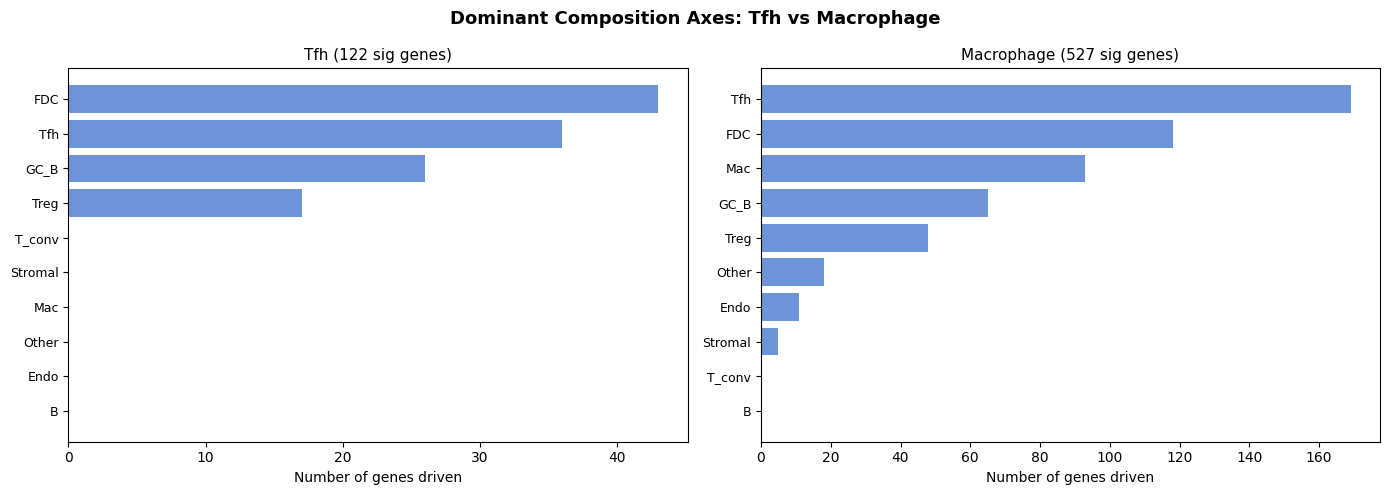

In [17]:
# Compare dominant composition axes between Tfh and Macrophage
beta_cols = [f'beta_{t}' for t in result.type_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dominant Composition Axes: Tfh vs Macrophage', fontsize=13, fontweight='bold')

for ax, (res, name) in zip(axes, [(result, 'Tfh'), (result_mac, 'Macrophage')]):
    sig_mask = res.significant
    if sig_mask.sum() == 0:
        continue
    betas = res.beta[sig_mask]
    drivers = np.argmax(np.abs(betas), axis=1)
    counts_per_axis = np.bincount(drivers, minlength=len(res.type_names))
    order = np.argsort(counts_per_axis)[::-1]
    ax.barh(range(len(res.type_names)), counts_per_axis[order],
            color='#4878CF', alpha=0.8)
    ax.set_yticks(range(len(res.type_names)))
    ax.set_yticklabels([res.type_names[i] for i in order], fontsize=9)
    ax.set_xlabel('Number of genes driven')
    ax.set_title(f'{name} ({sig_mask.sum()} sig genes)', fontsize=11)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## Summary

This tutorial demonstrated the complete AURA workflow:

1. **Data loading** — `load_adata()` with parameterized column names
2. **Single focal type analysis** — `run_aura()` returns an `AuraResult` with all outputs
3. **Diagnostics** — `diagnostic_panel()` validates null calibration and model fit
4. **Variance decomposition** — `variance_panel()` and `variance_summary()` quantify effect sizes
5. **SVD interpretation** — `result_panel()` reveals principal composition modes
6. **Gene-level deep dive** — `gene_zoom_panel()` for spatial + compositional validation
7. **Multi-focal comparison** — reuse the same workflow on any cell type

### Key findings in this lymph node

- **Tfh cells** show strong composition-dependent expression driven by the **GC_B axis**
  (germinal center proximity). Top genes include TOX2, IKZF3, CR2, MAF, PDCD1 — all
  known Tfh/GC biology.
- **Macrophages** show a different composition signature, reflecting their distinct
  spatial niches (subcapsular, paracortical, medullary).
- Shared context-responsive genes (e.g., CCL19, DPT) suggest broadly
  position-dependent programs that span cell types.

### Next steps

- Run AURA on additional focal types (GC_B, Endothelial, Treg, etc.)
- Apply to other tissues (e.g., IPF lung, tumor microenvironment)
- Use `run_model_sample()` for TMA or multi-sample designs where composition
  varies across samples rather than within a single slide